# 디퓨전 모델 공부하기
https://huggingface.co/docs/diffusers/main/tutorials/basic_training

In [1]:
from huggingface_hub import notebook_login

notebook_login()

# 학습 설정

In [2]:
from dataclasses import dataclass

# dataclass는 데이터만 담는 클래스를 편하게 만들기 위한 Python 기능
# 자동으로 기본 인자 설정을 해줌
# 클래스 어노테이션이 없으면 dataclass의 field로 인식되지 않게 됨
@dataclass
class TrainingConfig:
    image_size = 128
    train_batch_size=16                 # 학습 한번에 GPU에 넣을 이미지 개수
    eval_batch_size=16                  # 평가 1번에 GPU에 넣을 이미지 개수
    num_epochs=50
    gradient_accumulation_steps = 1     # gradient가 몇 step을 모은 뒤 optimizer.step()을 할지 결정
    learning_rate = 1e-4
    lr_warmup_steps = 500               # 학습 초반 500 step 동안 learning rate를 천천히 올려주기 (초반부터 너무 많이 올리면 학습이 불안정해짐)
    save_image_epochs = 10              # 10 epoch 마다 학습된 모델로 이미지를 생성해서 저장
    save_model_epochs = 30              # 30 epoch마다 학습된 모델과 checkpoint를 저장
    mixed_precision = "fp16"            # 일부 연산을 fp16으로 수행하겠다는 의미
    output_dir = "ddpm-butterflies-128" # 모델, 생성 이미지, checkpoint 등의 결과물을 저장할 디렉ㄱ토리 명

    push_to_hub = True                  # 코드에서 Hub 업로드 가능하게 해주는 기능
    hub_model_id = "hurwan/first-diffusion"
    hub_private_repo = None             # 올린 repo를 private로 만들지에 대한 설정
    overwrite_output_dir = None         # 기존에 이미 있으면 덮어쓸지
    seed = 0

config = TrainingConfig()

# 데이터셋 불러오기

In [5]:
from datasets import load_dataset

config.dataset_name = "huggan/smithsonian_butterflies_subset"
dataset = load_dataset(config.dataset_name, split="train")

README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hurwa\.cache\huggingface\hub\datasets--huggan--smithsonian_butterflies_subset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.65k [00:00<?, ?B/s]

C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hurwa\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  237MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [6]:
type(dataset), dataset.shape

(datasets.arrow_dataset.Dataset, (1000, 18))

In [11]:
len(dataset["image"]), type(dataset["image"][0])

(1000, PIL.PngImagePlugin.PngImageFile)

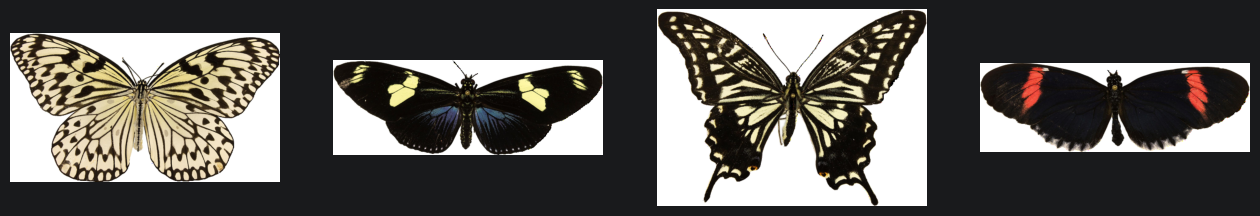

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, image in enumerate(dataset[:4]["image"]):
    axes[i].imshow(image)
    axes[i].set_axis_off()

plt.show()

In [14]:
from torchvision import transforms

preprocess = transforms.Compose(
    [
        transforms.Resize((config.image_size, config.image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]
)

In [15]:
def transform(examples):
    """examples는 arrow_dataset.Dataset 형태를 기대함"""
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

In [17]:
import torch

train_dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=config.train_batch_size,
    shuffle=True
)

In [19]:
from diffusers import UNet2DModel

model = UNet2DModel(
    # 들어오는 H, W를 (samlpe_size, sample_size)로 기대
    sample_size=config.image_size,
    # RGB 같은 채널 3개를 받아서 공간 압축 후
    in_channels=3,
    # 다시 RGB같은 3채널 이미지로 복원
    out_channels=3,
    # 하나의 블럭당 사용할 특징을 가공하는 layer 개수
    # 여기에서 넣는 건 ResNet 계열 layer
    layers_per_block=2,
    # DownBlock에서 사용할 feature channel 수
    block_out_channels=(128, 128, 256, 256, 512, 512),

    # noisy image를 받아서 노이즈를 예측해주기
    # ※ 중요한 부분으로는 skip connection을 통해 대칭되는 Down과 Up의 Block에서 Down 과정에서 얻은 feature을 그대로 Up 블럭으로 전달해줌
    down_block_types=(  # 여기에서 공간의 크기를 줄이고 특징 채널을 많게 만들기
        # Convolution + Resnet으로 주변 특징 처리
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        # Conv + Resnet -> attention으로 멀리 떨어진 위치 관계 확인
        "AttnDownBlock2D",
        "DownBlock2D"
    ),
    up_block_types=(    # 여기에서 다시 공간 크기를 키우면서 특징을 복원시키기
        # 동일하게 Upsampling + Resnet 처리
        "UpBlock2D",
        # UpBlock + Attention
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
    )
    # 최종적으로 이미지에 존재하는 \epslion이 무엇일지 예측하게 됨
)

In [20]:
# 이미지 하나를 가져와서 [B, 이미지] 형태로 가져오기
sample_image = dataset[0]["images"].unsqueeze(0)
print("Input shape:", sample_image.shape)

# 모델 돌려서 출력이 어떤 형태로 나오는지 확인하기
print("Output shape:", model(sample_image,timestep=0).sample.shape)

Input shape: torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 3, 128, 128])


In [ ]:
import torch
from PIL import Image
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
noise = torch.randn(sample_image.shape)
timesteps = torch.LongTensor([50])
noisy_image = noise_scheduler.add_noise(sample_image, noise, timesteps)

Image.fromarray(((noisy_image.permute(0, 2, 3, 1) + 1.0) * 127.5).type(torch.uint8))